<a href="https://colab.research.google.com/github/nurahmi-tintyasusi-dev/data-science-2026/blob/main/Pertemuan4_Nurahmi_Tintyasusi_250401020035.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : NURAHMI TINTYASUSI

NIM : 250401020035

Kelas : IF401

Mata Kuliah : Data Science


---



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


Load dataset Iris

In [ ]:
df_iris = sns.load_dataset('iris')
print(f"Ukuran dataset: {df_iris.shape}")
print(f"Tipe data:\n{df_iris.dtypes}")
print(f"\n5 baris pertama:\n{df_iris.head()}")
print(f"\nStatistik deskriptif:\n{df_iris.describe().round(3)}")

Ukuran dataset: (150, 5)
Tipe data:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

5 baris pertama:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Statistik deskriptif:
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.35

Analisis statistik deskriptif per kolom numerik

In [ ]:
for kolom in df_iris.select_dtypes(include='number').columns:
    data_kolom = df_iris[kolom]
    print(f"\n=== {kolom} ===")
    print(f"Mean    : {data_kolom.mean():.3f}")
    print(f"Median  : {data_kolom.median():.3f}")
    print(f"Std Dev : {data_kolom.std():.3f}")
    print(f"Skewness: {data_kolom.skew():.3f}")
    print(f"Kurtosis: {data_kolom.kurt():.3f}")


=== sepal_length ===
Mean    : 5.843
Median  : 5.800
Std Dev : 0.828
Skewness: 0.315
Kurtosis: -0.552

=== sepal_width ===
Mean    : 3.057
Median  : 3.000
Std Dev : 0.436
Skewness: 0.319
Kurtosis: 0.228

=== petal_length ===
Mean    : 3.758
Median  : 4.350
Std Dev : 1.765
Skewness: -0.275
Kurtosis: -1.402

=== petal_width ===
Mean    : 1.199
Median  : 1.300
Std Dev : 0.762
Skewness: -0.103
Kurtosis: -1.341


Visualisasi histogram sepal_length

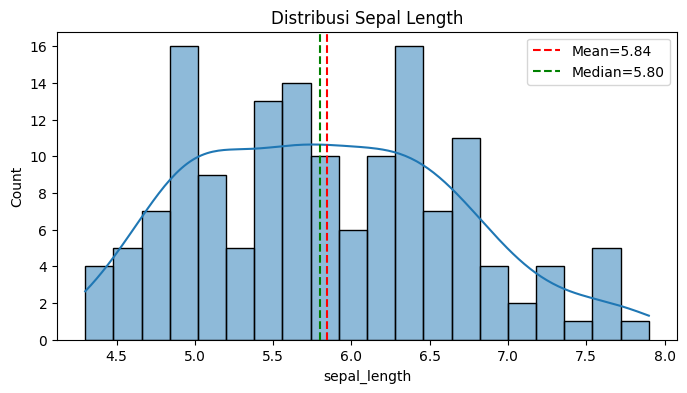

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df_iris['sepal_length'], kde=True, color='#1f77b4', bins=20, ax=ax)
ax.axvline(df_iris['sepal_length'].mean(), color='red', linestyle='--',
           label=f"Mean={df_iris['sepal_length'].mean():.2f}")
ax.axvline(df_iris['sepal_length'].median(), color='green', linestyle='--',
           label=f"Median={df_iris['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length')
ax.legend()
plt.show()


Visualisasi boxplot dan violin plot petal_length

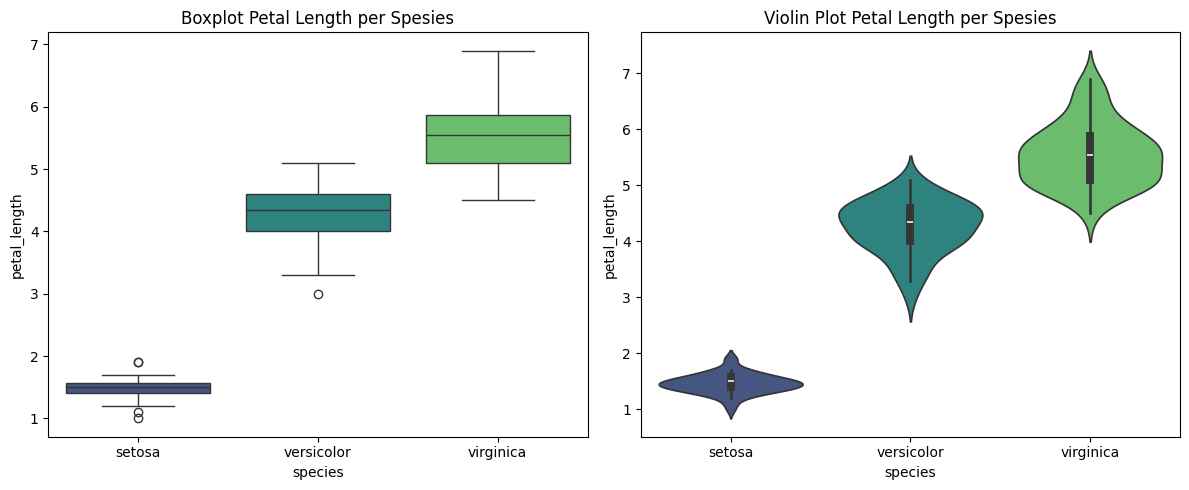

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_iris, x='species', y='petal_length', hue='species',
            palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Boxplot Petal Length per Spesies')
sns.violinplot(data=df_iris, x='species', y='petal_length', hue='species',
               palette='viridis', legend=False, inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length per Spesies')
plt.tight_layout()
plt.show()


Analisis korelasi antar fitur

In [ ]:
matriks_korelasi = df_iris.drop('species', axis=1).corr(method='pearson')
print("Matriks Korelasi:")
print(matriks_korelasi.round(3))

# Cari korelasi tertinggi
import numpy as np
mask = np.triu(np.ones(matriks_korelasi.shape, dtype=bool))
korelasi_masked = matriks_korelasi.where(~mask)
pasangan_tertinggi = korelasi_masked.stack().idxmax()
print(f"\nKorelasi tertinggi: {pasangan_tertinggi} = {matriks_korelasi.loc[pasangan_tertinggi]:.3f}")

Matriks Korelasi:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


Visualisasi scatter plot dan heatmap korelasi

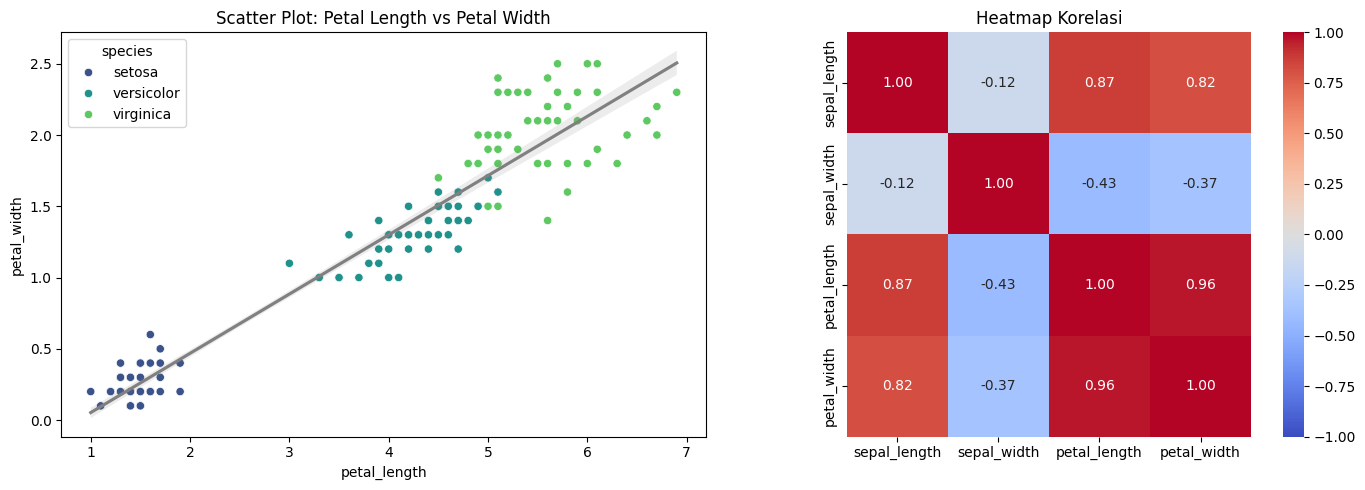

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df_iris, x='petal_length', y='petal_width',
                hue='species', palette='viridis', ax=axes[0])
sns.regplot(data=df_iris, x='petal_length', y='petal_width',
            scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter Plot: Petal Length vs Petal Width')
sns.heatmap(matriks_korelasi, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout()
plt.show()


KESIMPULAN :


*   **Apa yang dipelajari:** Menerapkan seluruh teknik pada dataset nyata menggunakan Python di Google
Colab.
*   **Temuan Utama:** Ditekankan bahwa nilai korelasi yang tinggi tidak sama dengan hubungan kausalitas (sebab-akibat), karena ada kemungkinan pengaruh dari variabel ketiga (confounding variable).
*   **Keterbatasan/Pertanyaan:** Pada pembuatan histogram, penentuan jumlah interval (bins) yang kurang tepat dapat menghilangkan detail penting data (jika terlalu sedikit) atau menghasilkan visualisasi yang terlalu berisik (jika terlalu banyak).

